<a href="https://colab.research.google.com/github/OPthyago/TECH-CHALLENGE-FASE-1/blob/isabella/notebooks/TechChallenge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Libs - Exploração e Manipulação de dados
import pandas as pd
import numpy as np

# Libs Graficas
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Avisos
import warnings
warnings.filterwarnings("ignore")

nps = pd.read_csv("../data/desafio_nps_fase_1.csv")

nps.head()

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9


In [3]:
print(f'Visão geral da base: contém {nps["customer_id"].nunique()} registros sem valores numos, o que indica boa qualidade dos dados para análise.')

Visão geral da base: contém 2500 registros sem valores numos, o que indica boa qualidade dos dados para análise.


Verificar se existe valor Nulos no dataset

In [4]:
print('A seguir os principais números que descrevem os indicadores macro da experiência dos clientes')
nps.describe().round(2)

A seguir os principais números que descrevem os indicadores macro da experiência dos clientes


,customer_id,customer_age,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
count,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00
mean,1250.50,43.40,61.32,51250.50,434.26,3.47,29.75,6.00,8.02,2.19,38.22,2.01,1.52,5.49,4.38,0.09,4.15,2.94
std,721.83,14.89,34.48,721.83,289.77,1.69,29.23,3.16,3.77,1.45,12.08,0.82,1.23,3.46,2.51,0.28,1.78,2.38
min,1.00,18.00,1.00,50001.00,7.76,1.00,0.02,1.00,2.00,0.00,2.62,1.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,625.75,31.00,31.00,50625.75,220.24,2.00,8.88,3.00,5.00,1.00,29.93,1.00,1.00,2.00,2.60,0.00,3.00,0.70
50%,1250.50,43.00,62.00,51250.50,375.52,3.00,20.94,6.00,8.00,2.00,38.50,2.00,1.00,6.00,4.40,0.00,4.00,2.80
75%,1875.25,56.00,91.00,51875.25,577.29,5.00,40.83,9.00,11.00,3.00,46.27,3.00,2.00,8.00,6.10,0.00,5.00,4.80
max,2500.00,69.00,119.00,52500.00,1983.81,6.00,230.33,11.00,14.00,8.00,76.13,3.00,7.00,11.00,10.00,1.00,11.00,10.00


In [5]:
print(f'NPS médio de {nps['nps_score'].mean():.2f}')

print(f'75% dos clientes têm NPS de até {nps['nps_score'].quantile(0.75)}')

print(f'Apenas {nps['repeat_purchase_30d'].mean()*100:.2f}% dos clientes recompram em 30 dias')

print(f'Média de reclamações por pedido {nps['complaints_count'].mean():.2f}')

NPS médio de 4.38
75% dos clientes têm NPS de até 6.1
Apenas 8.72% dos clientes recompram em 30 dias
Média de reclamações por pedido 4.15


In [6]:
# Criação das categorias
nps['nps_category'] = pd.cut(
    nps['nps_score'],
    bins=[0, 6, 8, 10],
    labels=['Detrator', 'Neutro', 'Promotor'],
    include_lowest=True
)

contagem = nps['nps_category'].value_counts()
distribuicao = nps['nps_category'].value_counts(normalize=True) * 100

detratores=distribuicao['Detrator']
neutros=distribuicao['Neutro']
promotores=distribuicao['Promotor']

print(f'A base é composta por {contagem['Detrator']} ({detratores:.1f}%) detratores, {contagem['Neutro']} ({neutros:.1f}%) neutros e {contagem['Promotor']} ({promotores:.1f}%) promotores')


A base é composta por 1851 (74.0%) detratores, 448 (17.9%) neutros e 201 (8.0%) promotores


### Nota-se a predominância de detratores, um grande indicativo de um cenário crítico de insatisfação dos clientes, a grande maioria acabam não recomendando a empresa.

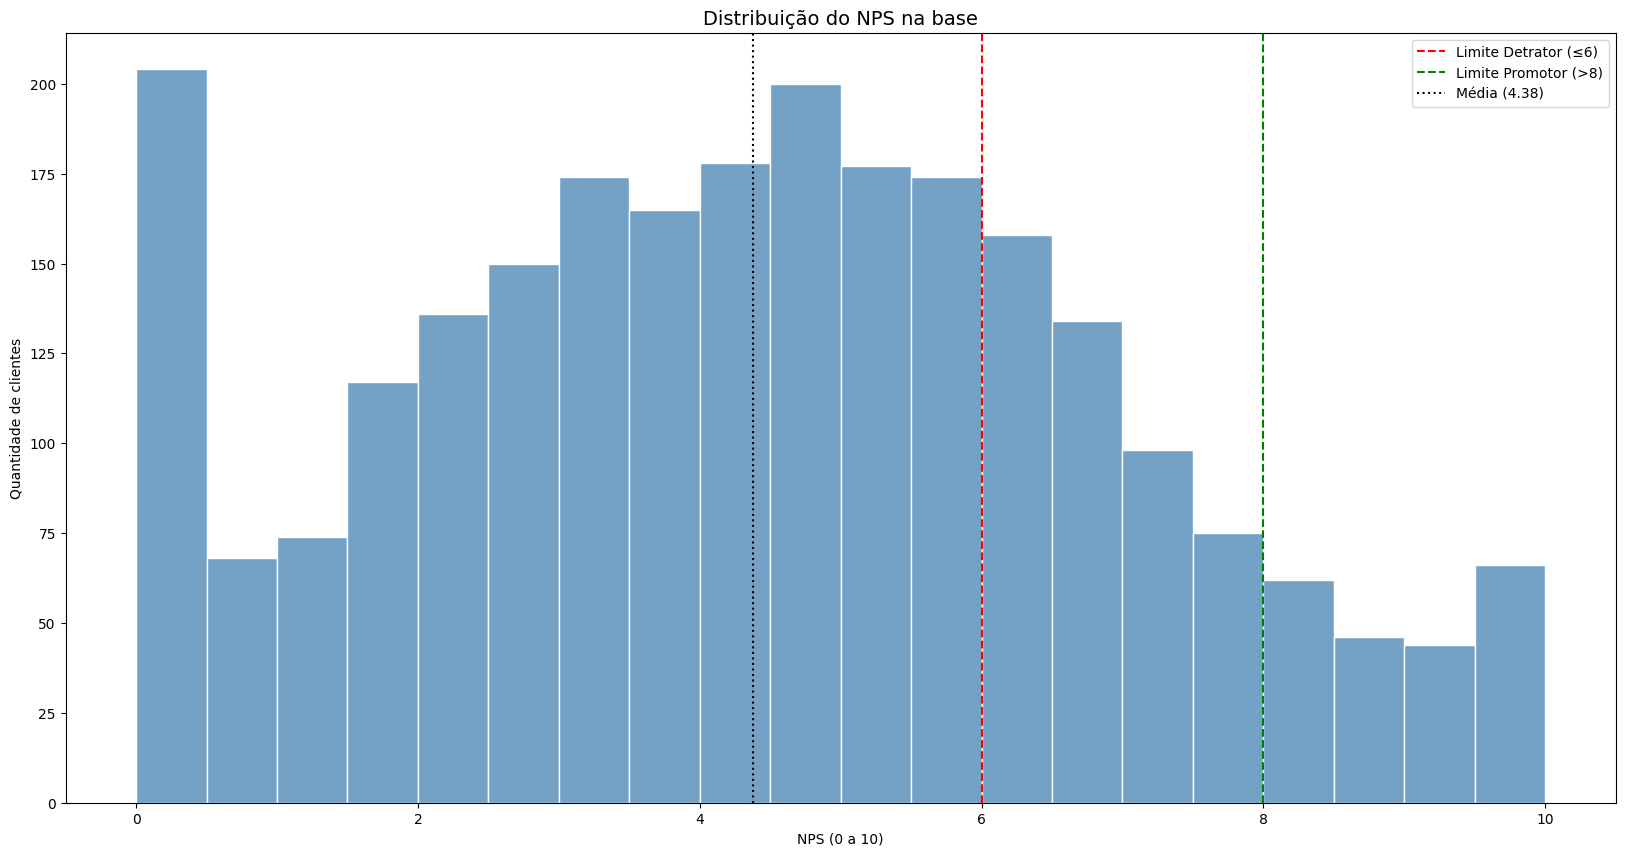

In [7]:
plt.figure(figsize=(20, 10))

sns.histplot(
    data=nps,
    x='nps_score',
    bins=20,
    color='steelblue',
    edgecolor='white'
)

# Linhas verticais marcando os cortes Detrator / Neutro / Promotor
plt.axvline(x=6, color='red', linestyle='--', label='Limite Detrator (≤6)')
plt.axvline(x=8, color='green', linestyle='--', label='Limite Promotor (>8)')

# Linha vertical da média (extra: ajuda a comunicar o cenário)
plt.axvline(x=nps['nps_score'].mean(), color='black', linestyle=':', label=f'Média ({nps["nps_score"].mean():.2f})')

plt.title('Distribuição do NPS na base', fontsize=14)
plt.xlabel('NPS (0 a 10)')
plt.ylabel('Quantidade de clientes')
plt.legend()

plt.show()

### Distribuição do NPS — análise visual

Para visualizar a distribuição do `nps_score`, foram testados diferentes valores de `bins` (número de faixas em que os dados são agrupados). A escolha do `bins` influencia diretamente o nível de detalhe do histograma: poucos `bins` mostram a tendência geral, enquanto muitos `bins` revelam padrões mais finos.

Optou-se por **`bins=20`** por permitir uma leitura mais detalhada da distribuição. Uma versão com `bins=11` foi testada (uma barra por nota inteira do NPS), mas ela agrupava demais os dados e ocultava um padrão importante que será descrito a seguir.

**O que o gráfico revela:**

- A distribuição não é uniformemente baixa, como a média (4.38) poderia sugerir. Ela é **bimodal**: apresenta dois picos distintos.
- O primeiro pico está próximo de **NPS 0**, com aproximadamente 200 clientes — possivelmente os "muito insatisfeitos", que tiveram experiências severamente negativas.
- O segundo pico está na faixa de **NPS 4-5**, também com cerca de 200 clientes — uma insatisfação mais moderada.
- Entre esses dois picos há um **vale** (NPS 1-2), com menos clientes.
- A partir do NPS 6 a distribuição cai consistentemente, confirmando a baixa representatividade de promotores.
- Há ainda um pequeno aumento isolado próximo de **NPS 10**, sugerindo a existência de um grupo pequeno de clientes muito satisfeitos.

**Implicação para o negócio:**

A bimodalidade indica que os detratores não formam um grupo único. Existem ao menos dois perfis distintos de clientes insatisfeitos, possivelmente com causas diferentes para a insatisfação. Isso sugere que, ao investigar os fatores que impactam o NPS, vale a pena analisar esses subgrupos separadamente — uma recomendação de melhoria que funciona para um grupo pode não funcionar para o outro.

In [23]:
#Setup da matriz de correlação
colunas_para_remover = ['customer_id', 'order_id']
colunas_numericas = nps.select_dtypes(include=['number']).drop(columns=colunas_para_remover).columns

# Calcular a matriz de correlação
matriz_corr = nps[colunas_numericas].corr()

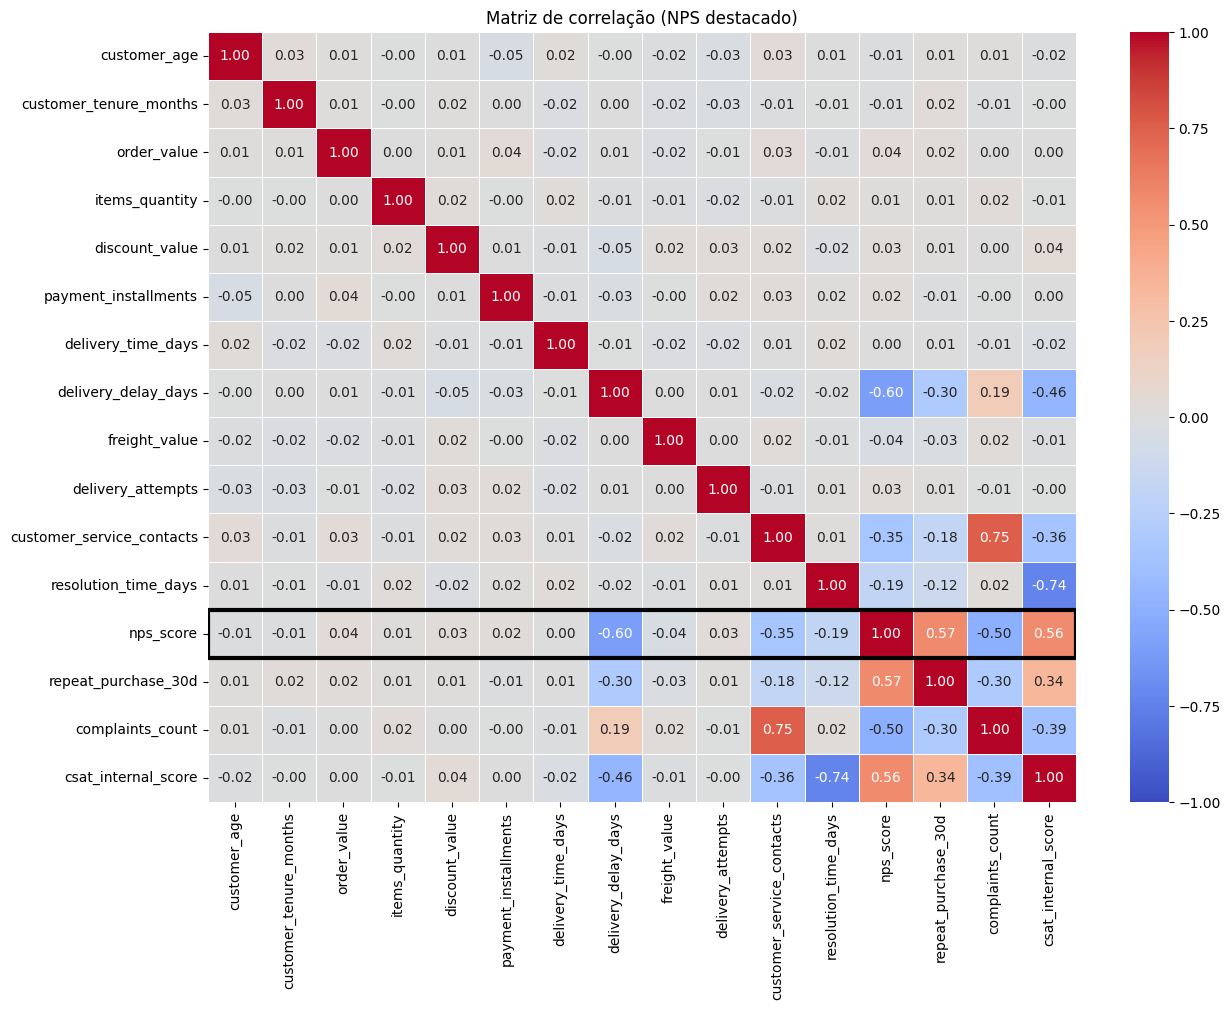

In [22]:
plt.figure(figsize=(14, 10))
sns.heatmap(
    matriz_corr,
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt='.2f',
    vmin=-1,
    vmax=1,
    linewidths=0.5,
)
# Destacar a linha do nps_score com uma borda
nps_index = list(matriz_corr.columns).index('nps_score')
plt.gca().add_patch(plt.Rectangle((0, nps_index), len(matriz_corr.columns), 1, fill=False, edgecolor='black', lw=3))

plt.title('Matriz de correlação (NPS destacado)')
plt.show()

### Correlação das variáveis com o NPS

A matriz de correlação apresenta todas as variáveis cruzadas entre si, o que dificulta identificar rapidamente quais delas mais se relacionam com o NPS. Este gráfico isola apenas a relação de cada variável com o `nps_score` e a ordena, permitindo responder de forma direta: quais fatores estão associados a um NPS menor e quais a um NPS maior?

A cor indica o sentido da relação: vermelho para relações negativas (a variável aumenta e o NPS tende a cair) e verde para positivas (ambas sobem juntas).

**O que o gráfico mostra:**

- Do lado negativo (vermelho) aparecem variáveis ligadas a problemas na operação: atraso na entrega, reclamações e contatos com o atendimento. São as que mais reduzem o NPS.

- Do lado positivo (verde) aparecem variáveis ligadas à satisfação e à fidelidade do cliente. A relação é coerente, mas exige cuidado na interpretação (detalhado abaixo).
  
- A maioria das variáveis ligadas à compra em si (valor do pedido, frete, parcelas, desconto, idade e tempo de relacionamento) fica próxima de zero, ou seja, quase não diferencia um cliente satisfeito de um insatisfeito.

**Relevância para a priorização:**

O tamanho das barras indica onde concentrar atenção. As variáveis negativas estão ligadas a fatores que a empresa consegue melhorar, como o prazo de entrega e a qualidade do atendimento. Já as variáveis positivas mais fortes parecem ser mais uma consequência de o cliente já estar satisfeito do que uma causa, e por isso não servem diretamente como ponto de melhoria.

> **Cuidado na interpretação:** a correlação indica que duas variáveis variam juntas, mas não prova que uma causa a outra. Variáveis como `repeat_purchase_30d` e `csat_internal_score` têm correlação alta com o NPS em parte porque medem a mesma satisfação por outro ângulo, ou ocorrem depois dela.

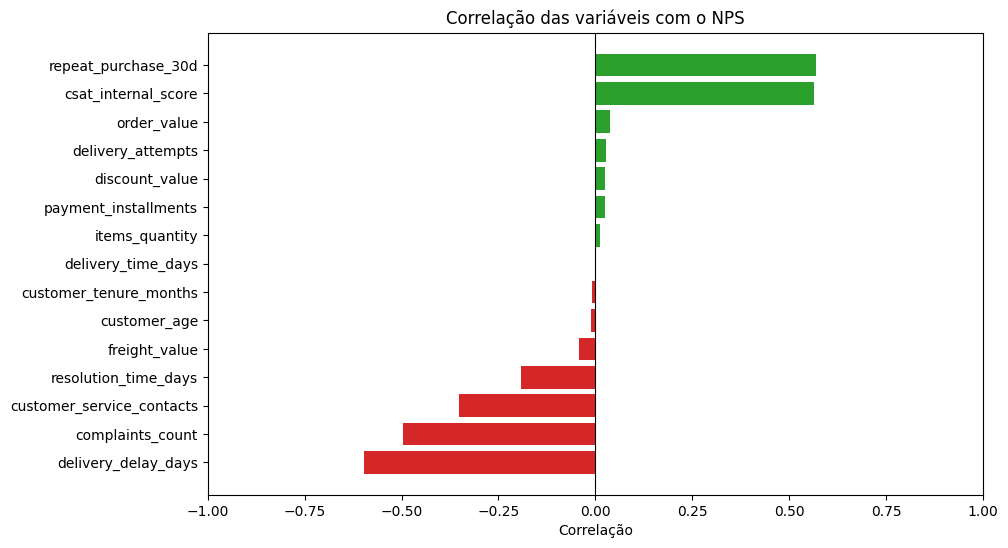

In [19]:
corr_nps = matriz_corr['nps_score'].drop('nps_score').sort_values()

plt.figure(figsize=(10, 6))
cores = ['#d62728' if x < 0 else '#2ca02c' for x in corr_nps.values]
plt.barh(corr_nps.index, corr_nps.values, color=cores)
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title('Correlação das variáveis com o NPS')
plt.xlabel('Correlação')
plt.xlim(-1, 1)
plt.show()


### Ranking de impacto no NPS — direção e magnitude

Enquanto o heatmap acima mostra todas as relações entre as variáveis, estegráfico isola apenas a coluna do `nps_score` e a ordena. O objetivo é responder a uma pergunta direta: **quais fatores puxam o NPS para baixo e quais puxam para cima, em ordem de força?**

A cor codifica o sinal da correlação — vermelho para relação negativa (quando a variável aumenta, o NPS tende a cair) e verde para positiva.

**Leitura do gráfico:**

- O lado vermelho (negativo) é dominado por variáveis de **falha operacional e atrito**: atraso de entrega, reclamações e contatos com o
  atendimento. São os principais destruidores de NPS na base.
- O lado verde (positivo) é puxado por variáveis que medem **satisfação já manifestada ou comportamento de fidelidade** — o que é coerente, mas exige cautela analítica (ver observação abaixo).
- A maior parte das variáveis transacionais (valor do pedido, frete, parcelas, desconto, idade, tempo de relacionamento) fica colada no zero: não distingue cliente satisfeito de insatisfeito.

**Por que isso importa para a priorização:**

O comprimento das barras indica onde concentrar esforço. As variáveis operacionais negativas são **acionáveis** — a empresa controla prazo de entrega e qualidade de atendimento. Já as variáveis positivas mais fortes tendem a ser *consequência* da satisfação, não *causa* dela, e portanto não servem como alavanca direta.

> **Atenção a interpretação causal:** correlação aqui mede associação linear, não causa. Variáveis como `repeat_purchase_30d` e `csat_internal_score` correlacionam alto com NPS em parte porque medem a mesma satisfação por outro ângulo (ou ocorrem depois dela).

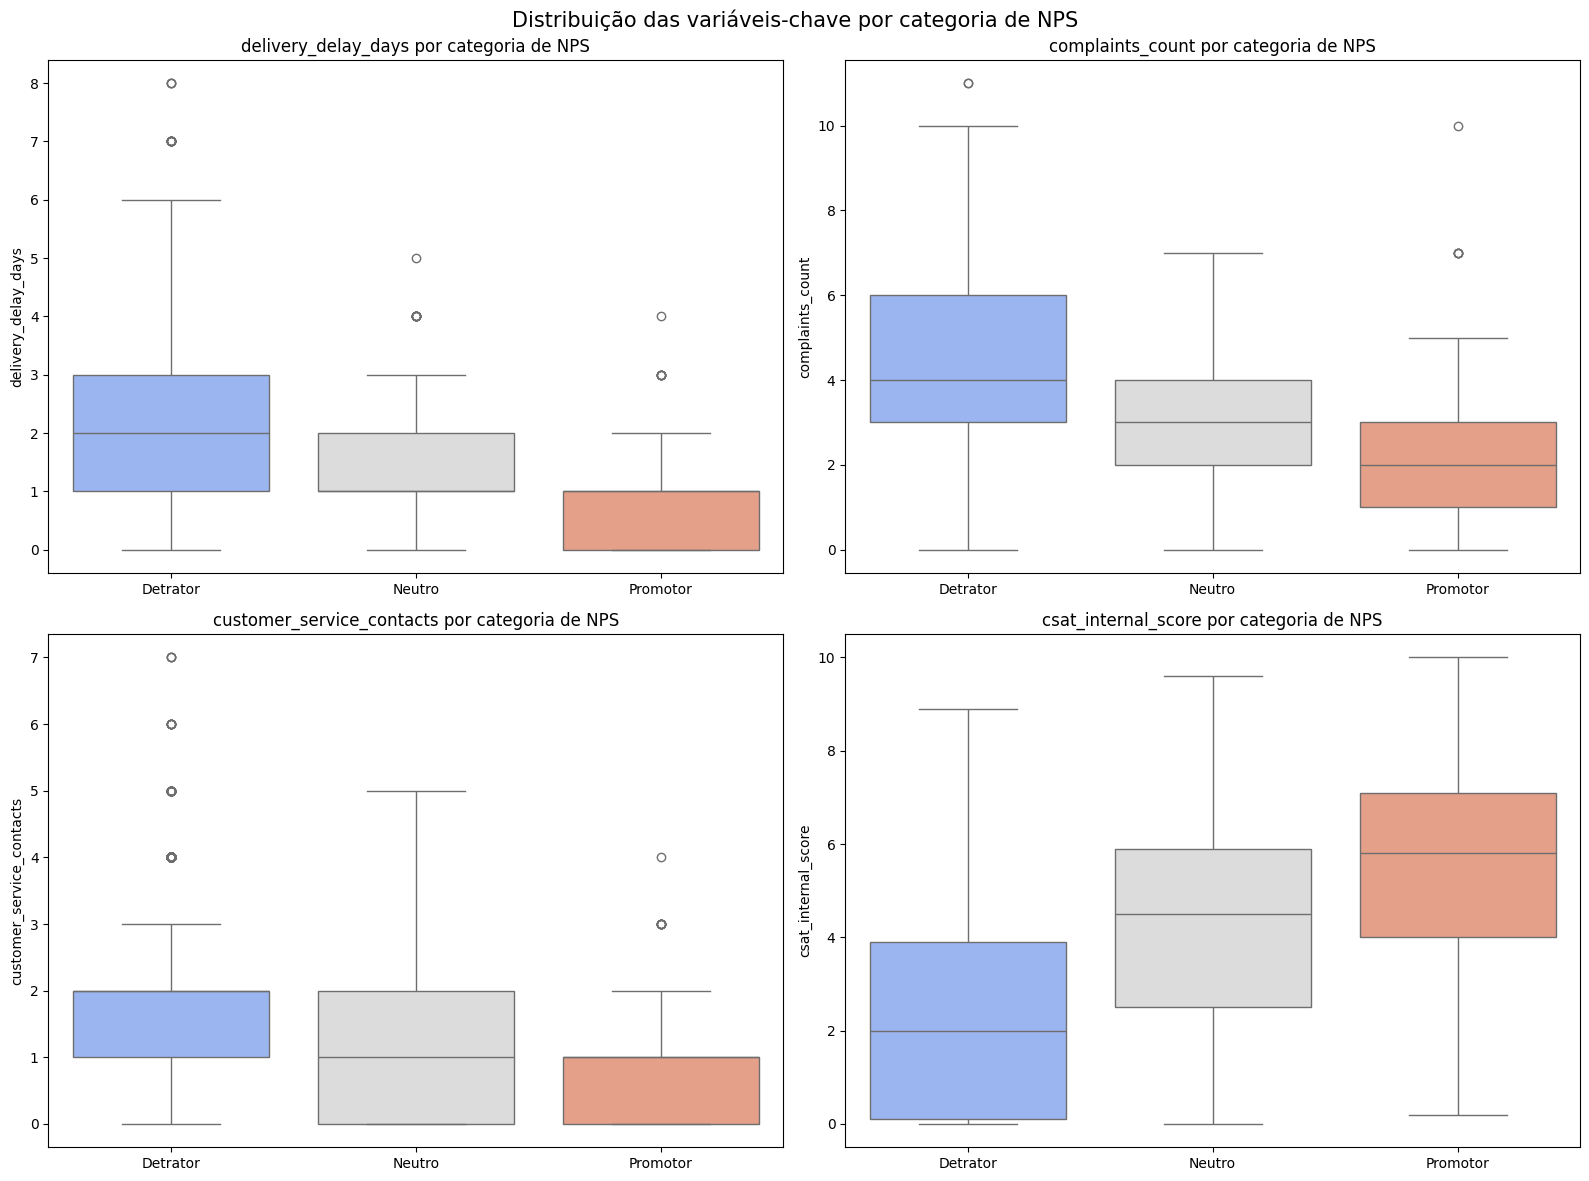

In [25]:
variaveis = ['delivery_delay_days', 'complaints_count',
             'customer_service_contacts', 'csat_internal_score']
ordem_cat = ['Detrator', 'Neutro', 'Promotor']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for ax, var in zip(axes, variaveis):
    sns.boxplot(
        data=nps,
        x='nps_category',
        y=var,
        order=ordem_cat,
        ax=ax,
        showfliers=True,
        palette='coolwarm'
    )
    ax.set_title(f'{var} por categoria de NPS')
    ax.set_xlabel('')
    ax.set_ylabel(var)

plt.suptitle('Distribuição das variáveis-chave por categoria de NPS', fontsize=15)
plt.tight_layout()
plt.show()

### Distribuição das variáveis-chave por categoria de NPS

Após identificar no gráfico de correlação quais variáveis se relacionam com o NPS, esta etapa analisa como elas se comportam em cada grupo de cliente. As quatro variáveis mais relevantes foram separadas entre Detrator, Neutro e Promotor por meio de boxplots.

**Observações de cada gráfico:**

- **`delivery_delay_days`:** os detratores apresentam os maiores atrasos, enquanto os promotores quase não têm atraso. Os atrasos mais altos (5 dias ou mais) aparecem quase exclusivamente entre os detratores, o que indica que atrasos grandes prejudicam de forma significativa a satisfação do cliente.

- **`complaints_count`:** quanto maior o número de reclamações, menor o NPS. A diferença entre os grupos é clara, com a quantidade de reclamações caindo do Detrator para o Promotor.

- **`customer_service_contacts`:** o comportamento é muito semelhante ao de reclamações. Isso é esperado, já que na matriz de correlação essas duas variáveis têm correlação alta entre si (0,75) e provavelmente representam a mesma situação: o cliente que reclama é o mesmo que aciona o atendimento.

- **`csat_internal_score`:** foi a única variável com comportamento inverso às demais. A nota sobe do Detrator para o Promotor, indicando que quanto maior a satisfação interna, maior o NPS.

**Consideração sobre a separação dos grupos:**

As diferenças entre os grupos existem, porém são moderadas. As caixas de grupos vizinhos (como Detrator e Neutro) ficam próximas e se sobrepõem, o que é coerente com correlações de intensidade média (entre 0,35 e 0,60), e não próximas de 1. Na prática, essas variáveis ajudam mais a diferenciar os extremos (Detrator e Promotor) do que os grupos intermediários. Dessa forma, nenhuma variável isolada explica o NPS, o padrão se revela na combinação delas.